In [137]:
from sklearn.linear_model import LogisticRegression
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler

In [138]:
file_path = r'C:\Users\paton\Downloads\Medicaldataset.csv'
df = pd.read_csv(file_path)

In [139]:
df.head()

,Age,Gender,Heart rate,Systolic blood pressure,Diastolic blood pressure,Blood sugar,CK-MB,Troponin,Result
0,64,1,66,160,83,160.0,1.80,0.012,negative
1,21,1,94,98,46,296.0,6.75,1.060,positive
2,55,1,64,160,77,270.0,1.99,0.003,negative
3,64,1,70,120,55,270.0,13.87,0.122,positive
4,55,1,64,112,65,300.0,1.08,0.003,negative


In [140]:
df['Result'] = df['Result'].map({'negative':0,'positive':1})
features = ['Age','Gender','Heart rate','Systolic blood pressure','Diastolic blood pressure','Blood sugar']

In [141]:
X = df[['Age','Gender','Heart rate','Systolic blood pressure','Diastolic blood pressure','Blood sugar']]

In [142]:
q1 = X.quantile(0.25)
q3 = X.quantile(0.75)
IQR = q3-q1 
lower = q1-1.5*IQR 
upper = q3+1.5*IQR
outliers = (X < lower) | (X > upper)
mask = outliers.any(axis=1)
outliers.sum()
df_cleaned = df[~mask]
X = df_cleaned[['Age','Gender','Heart rate','Systolic blood pressure','Diastolic blood pressure','Blood sugar']]
y = df_cleaned['Result']
df_cleaned


,Age,Gender,Heart rate,Systolic blood pressure,Diastolic blood pressure,Blood sugar,CK-MB,Troponin,Result
0,64,1,66,160,83,160.0,1.80,0.012,0
2,55,1,64,160,77,270.0,1.99,0.003,0
3,64,1,70,120,55,270.0,13.87,0.122,1
5,58,0,61,112,58,87.0,1.83,0.004,0
6,32,0,40,179,68,102.0,0.71,0.003,0
...,...,...,...,...,...,...,...,...,...
1313,86,0,40,179,68,147.0,5.22,0.011,0
1314,44,1,94,122,67,204.0,1.63,0.006,0
1315,66,1,84,125,55,149.0,1.33,0.172,1
1316,45,1,85,168,104,96.0,1.24,4.250,1


In [143]:
scaler = StandardScaler()

In [144]:
X_cleaned = scaler.fit_transform(X)

In [151]:
X_train, X_test, y_train, y_test = train_test_split(X_cleaned, y, test_size=0.3, random_state=42)

In [152]:
model = LogisticRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [153]:
print (accuracy_score(y_test,y_pred))

0.6609195402298851


In [154]:
print (classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.54      0.37      0.44       125
           1       0.70      0.83      0.76       223

    accuracy                           0.66       348
   macro avg       0.62      0.60      0.60       348
weighted avg       0.64      0.66      0.64       348



In [155]:
coefficients = pd.Series(model.coef_[0], index=features)
print("Feature Coefficients:")
print(coefficients.sort_values(ascending = False))

Feature Coefficients:
Age                         0.579395
Gender                      0.349988
Diastolic blood pressure    0.074866
Blood sugar                -0.009736
Heart rate                 -0.056272
Systolic blood pressure    -0.186454
dtype: float64


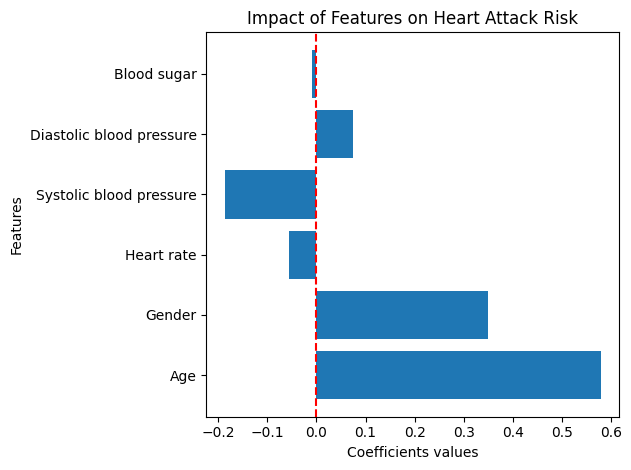

In [156]:
plt.barh(features,coefficients)
plt.title("Impact of Features on Heart Attack Risk")
plt.xlabel('Coefficients values')
plt.ylabel('Features')
plt.axvline(x=0, color='r',linestyle='--')
plt.tight_layout()
plt.show()